# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

In [3]:
# TODO: Setup environment and imports
# - Import torch, torchvision, numpy, matplotlib
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import random


# - Set random seeds and select device (cpu/cuda)
seed_Val = 42
random.seed(seed_Val)
np.random.seed(seed_Val)
torch.manual_seed(seed_Val)
device = "cuda" if torch.cuda.is_available() else "cpu"
# - Enable %matplotlib inline if needed
%matplotlib inline

In [2]:
# TODO: Load MNIST train/test datasets and create DataLoaders
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms



# - Apply ToTensor and Normalize transforms
data_transform=transforms.ToTensor()


# - Create train_loader and test_loader
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=data_transform)
test_dataset = FashionMNIST(root='./data', train=False, download=True, transform=data_transform)
train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)


100%|██████████| 26.4M/26.4M [01:56<00:00, 227kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 403kB/s]
100%|██████████| 4.42M/4.42M [00:18<00:00, 241kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.59MB/s]


In [3]:
# TODO: Define a small CNN suitable for MNIST (1x28x28 input)
# - Use Conv2d, ReLU, MaxPool2d, Linear layers
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
model = Net().to(device)


# - Return logits for 10 classes




In [4]:
# TODO: Set up optimizer and loss function
# - Choose Adam/SGD and CrossEntropyLoss
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# TODO: Implement a short training loop (2–3 epochs)
# - Print loss/accuracy per epoch
def train(epochs):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_i, data in enumerate(train_loader):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum()
            
            if batch_i % 1000 == 999:
                avg_loss = running_loss / 1000
                print(f'Epoch: {epoch + 1}, Batch: {batch_i+1}, Avg. Loss: {avg_loss:.4f}')
                running_loss = 0.0
        
        epoch_accuracy = 100 * correct.item() / total
        print(f'Epoch {epoch + 1}/{epochs} - Training Accuracy: {epoch_accuracy:.2f}%')
        

train(3)

Epoch: 1, Batch: 1000, Avg. Loss: 0.5582
Epoch: 1, Batch: 2000, Avg. Loss: 0.3523
Epoch: 1, Batch: 3000, Avg. Loss: 0.3051
Epoch 1/3 - Training Accuracy: 85.22%
Epoch: 2, Batch: 1000, Avg. Loss: 0.2747
Epoch: 2, Batch: 2000, Avg. Loss: 0.2587
Epoch: 2, Batch: 3000, Avg. Loss: 0.2435
Epoch 2/3 - Training Accuracy: 90.44%
Epoch: 3, Batch: 1000, Avg. Loss: 0.2151
Epoch: 3, Batch: 2000, Avg. Loss: 0.2175
Epoch: 3, Batch: 3000, Avg. Loss: 0.2090
Epoch 3/3 - Training Accuracy: 92.13%


In [5]:
# TODO: Evaluate on the test set and compute accuracy
# - Switch model to eval mode
# - Accumulate correct predictions and total
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()
accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 91.21%


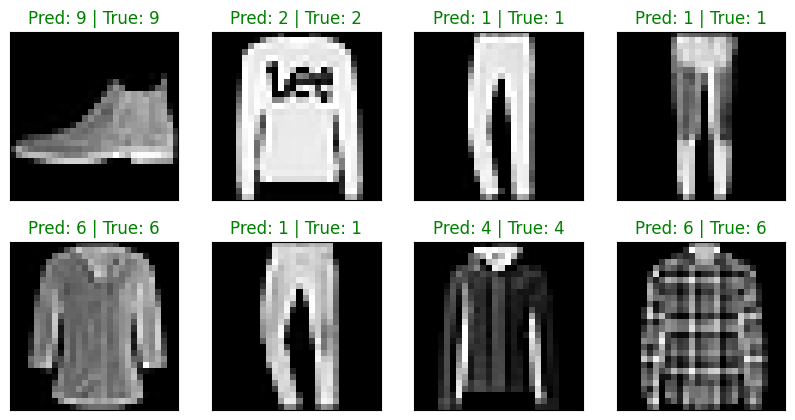

In [15]:
# TODO: Visualize a few test images with predicted and true labels
# - Sample a batch from test_loader
# - Run model and plot images with 'pred vs true' titles
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

fig = plt.figure(figsize=(10, 5))
for idx in range(8):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    ax.imshow(images[idx].squeeze(), cmap='gray')
    color = "green" if predicted[idx] == labels[idx] else "red"
    ax.set_title(f'Pred: {predicted[idx].item()} | True: {labels[idx].item()}', color=color)


## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [16]:
# TODO: Install ultralytics if needed (pip)
# %pip install ultralytics
%pip install ultralytics
# - Restart the kernel if required after installation

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



0: 640x640 1 umbrella, 1 frisbee, 1 kite, 96.1ms
Speed: 3.9ms preprocess, 96.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


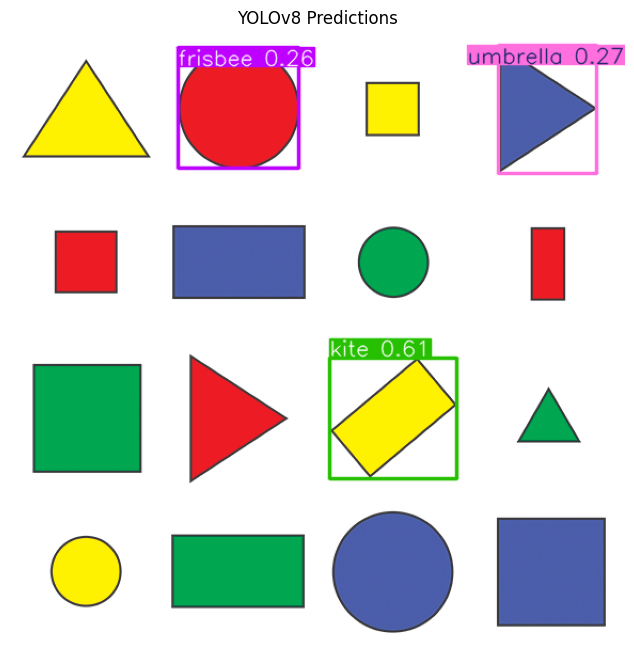

In [4]:
# TODO: Load a pretrained YOLOv8 model and run predictions on an image
# - Visualize results with matplotlib (convert BGR->RGB if using OpenCV)
from ultralytics import YOLO
import cv2
model = YOLO('yolov8n.pt')
img = cv2.imread('shapes.png')
results = model(img)

annotated_img = results[0].plot()  
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title("YOLOv8 Predictions")
plt.show()






## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [ ]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="NevjdMHzBjebiOIs9V3o")
project = rf.workspace("imagenes-lmahz").project("aerial-cars-rqcqh")
version = project.version(2)
dataset = version.download("yolov8")
                

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 MB 2.0 MB/s  0:00:26m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.3/892.3 kB 2.6 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.5 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: idna╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
    Found existing installation: idna 3.10m━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
    Uninstalling idna-3.10:m╺━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
      Successfully uninstalled idna-3.1090m━━━━━━━━━━━━━━━━━━━ 4/8 [opencv-python-headless]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [roboflow]6/8 [requests-toolbelt]]
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to aerial-cars-2 in yolov8:: 100%|██████████| 816/816 [00:00<00:00, 5074.57it/s]


In [19]:
# TODO: Provide path to your YOLOv8 data.yaml
# - Ensure train/val image directories and class names are correct
path_to_data_yaml = "/Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/data.yaml"

In [20]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)
model.train(data=path_to_data_yaml,epochs=3,imgsz=640)



New https://pypi.org/project/ultralytics/8.3.205 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.114 🚀 Python-3.9.6 torch-2.6.0 CPU (Apple M2)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/data.yaml, epochs=3, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=Fals

train: Scanning /Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/train/labels... 372 images, 0 backgrounds, 0 corrupt: 100%|██████████| 372/372 [00:00<00:00, 1680.81it/s]

train: New cache created: /Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/train/labels.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 181.9±103.7 MB/s, size: 76.2 KB)



val: Scanning /Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/valid/labels... 20 images, 1 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<00:00, 2575.33it/s]

val: New cache created: /Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/valid/labels.cache


...

                   all         20        478      0.662      0.258      0.287      0.165



3 epochs completed in 0.284 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 6.2MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics 8.3.114 🚀 Python-3.9.6 torch-2.6.0 CPU (Apple M2)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:05<00:00,  5.96s/it]


                   all         20        478      0.662      0.259      0.287      0.164
                     0         19        447      0.473      0.629       0.56      0.282
                     1          1          1          1          0          0          0
                     2         10         13      0.817      0.347      0.482      0.303
                     3         12         17      0.357     0.0588      0.106     0.0725
Speed: 1.1ms preprocess, 277.7ms inference, 0.0ms loss, 12.9ms postprocess per image
Results saved to runs/detect/train7


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x16403aaf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04


image 1/1 /Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/test/images/MOS74_png.rf.12922affff7bd6959bcca3dd144f3613.jpg: 640x640 12 0s, 85.0ms
Speed: 2.3ms preprocess, 85.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


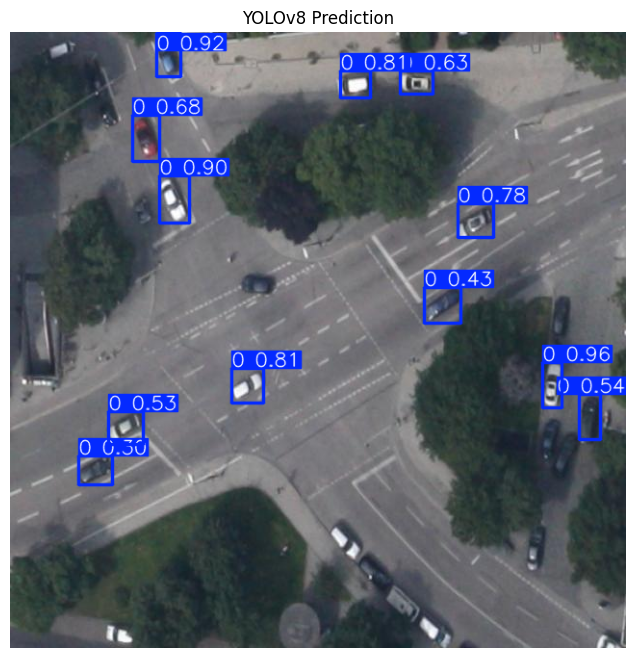

In [ ]:
# TODO: Run predictions with the trained YOLO model and visualize
# - Pick one or more images and display bounding boxes/labels
best_weights_path = "runs/detect/train7/weights/best.pt"
trained_model = YOLO(best_weights_path)
results = trained_model.predict("/Users/salma_khaled/SkyXperts-Vision-Course/tasks/task4/aerial-cars-2/test/images/MOS74_png.rf.12922affff7bd6959bcca3dd144f3613.jpg", show=False)

annotated_img = results[0].plot()
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title("YOLOv8 Prediction")
plt.show()

### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.